# ECE 227 Project

## Topic: 1 Network Analysis and Visualization using NetworkX and Gephi

## Group Members
- Jiayi Chen | A17496530 | jic101@ucsd.edu
- Junyi Wu | A17034047 | juw040@ucsd.edu
- Matthew Alegrado | A16752818 | malegrado@ucsd.edu
- Qinpei Luo | A69035113 | qpluo@ucsd.edu
- Zihao Yang | A16751774 | ziy019@ucsd.edu

## 1. Network Preparation

We download the following models:  
1. Collaboration: [GR-QC (General Relativity and Quantum Cosmology) collaboration network](https://snap.stanford.edu/data/ca-GrQc.html). 
2. Enron email network [Enron email network](https://snap.stanford.edu/data/email-Enron.html).  
3. Social circles: Facebook [Social circles: Facebook](https://snap.stanford.edu/data/ego-Facebook.html)

## 2. Load Networks

import networkx as nx

calibration = nx.read_edgelist("models/CA-GrQc.txt")
print("\nCalibration Network:")
print("Number of nodes:", calibration.number_of_nodes())
print("Number of edges:", calibration.number_of_edges())

facebook = nx.read_edgelist("models/facebook_combined.txt")
print("\nFacebook Network:")
print("Number of nodes:", facebook.number_of_nodes())
print("Number of edges:", facebook.number_of_edges())

email = nx.read_edgelist("models/Email-Enron.txt")
print("\nEmail-Enron Network:")
print("Number of nodes:", email.number_of_nodes())
print("Number of edges:", email.number_of_edges())


## 3. Centrality Analysis  
We analyze the degree, betweeness, closeness, and eigenvector centrality.

### (a) Collaboration Network: GRQC

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Collaboration network (CA-GrQc)
calibration = nx.read_edgelist("models/CA-GrQc.txt")

print("Collaboration Network:")
print("Number of nodes:", calibration.number_of_nodes())
print("Number of edges:", calibration.number_of_edges())
print("Is directed:", calibration.is_directed())
print("Is connected:", nx.is_connected(calibration))

Collaboration Network:
Number of nodes: 5242
Number of edges: 14496
Is directed: False
Is connected: False


Since the graph is not fully connected, we only select the connected sub graph

In [2]:
# Extract largest connected component
largest_cc = max(nx.connected_components(calibration), key=len)
G_cali = calibration.subgraph(largest_cc).copy()

print("Largest Connected Component:")
print("Nodes:", G_cali.number_of_nodes())
print("Edges:", G_cali.number_of_edges())

Largest Connected Component:
Nodes: 4158
Edges: 13428


We can see that the largest connected component doesn't shrink the graph too much.

Now let's check the centrality.

In [3]:
# Degree Centrality
deg_cent_grqc = nx.degree_centrality(G_cali)

# Betweenness Centrality
bet_cent_grqc = nx.betweenness_centrality(G_cali)

# Closeness Centrality
close_cent_grqc = nx.closeness_centrality(G_cali)

# Eigenvector Centrality
eig_cent_grqc = nx.eigenvector_centrality(G_cali, max_iter=1000)

In [4]:
def top_k(cent_dict, k=5):
    return sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:k]

top_degree = top_k(deg_cent_grqc)
top_between = top_k(bet_cent_grqc)
top_close = top_k(close_cent_grqc)
top_eigen = top_k(eig_cent_grqc)

print("Top 5 Degree Centrality:")
print(top_degree)

print("\nTop 5 Betweenness Centrality:")
print(top_between)

print("\nTop 5 Closeness Centrality:")
print(top_close)

print("\nTop 5 Eigenvector Centrality:")
print(top_eigen)

Top 5 Degree Centrality:
[('21012', 0.019485205677171036), ('21281', 0.01900408948761126), ('22691', 0.01852297329805148), ('12365', 0.01852297329805148), ('6610', 0.016357950445032476)]

Top 5 Betweenness Centrality:
[('13801', 0.05885863333957278), ('9572', 0.04083543405882196), ('14599', 0.04051657864826652), ('7689', 0.03969337449033517), ('13929', 0.039188090741565075)]

Top 5 Closeness Centrality:
[('13801', 0.24494726297802133), ('14485', 0.23896297999540125), ('9572', 0.23833276000458664), ('17655', 0.23823714826064532), ('2654', 0.23592508513053348)]

Top 5 Eigenvector Centrality:
[('21012', 0.15556177039105198), ('2741', 0.15357427925614384), ('12365', 0.1530719205320313), ('21508', 0.15119387808537754), ('9785', 0.15090318049267135)]


In [5]:
# Combine into one dataframe
df = pd.DataFrame({
    "Degree": pd.Series(deg_cent_grqc),
    "Betweenness": pd.Series(bet_cent_grqc),
    "Closeness": pd.Series(close_cent_grqc),
    "Eigenvector": pd.Series(eig_cent_grqc)
})

# Sort by degree for readability
df_sorted = df.sort_values("Degree", ascending=False)

df_sorted.head(10)

,Degree,Betweenness,Closeness,Eigenvector
21012,0.019485,0.018518,0.235191,0.155562
21281,0.019004,0.015328,0.225397,0.147963
12365,0.018523,0.017850,0.233631,0.153072
22691,0.018523,0.015541,0.232937,0.147038
9785,0.016358,0.011533,0.224678,0.150903
6610,0.016358,0.020294,0.229554,0.146743
21508,0.016117,0.005131,0.223675,0.151194
17655,0.015877,0.028611,0.238237,0.148260
2741,0.015636,0.009325,0.231562,0.153574
19423,0.015155,0.011278,0.224424,0.147840


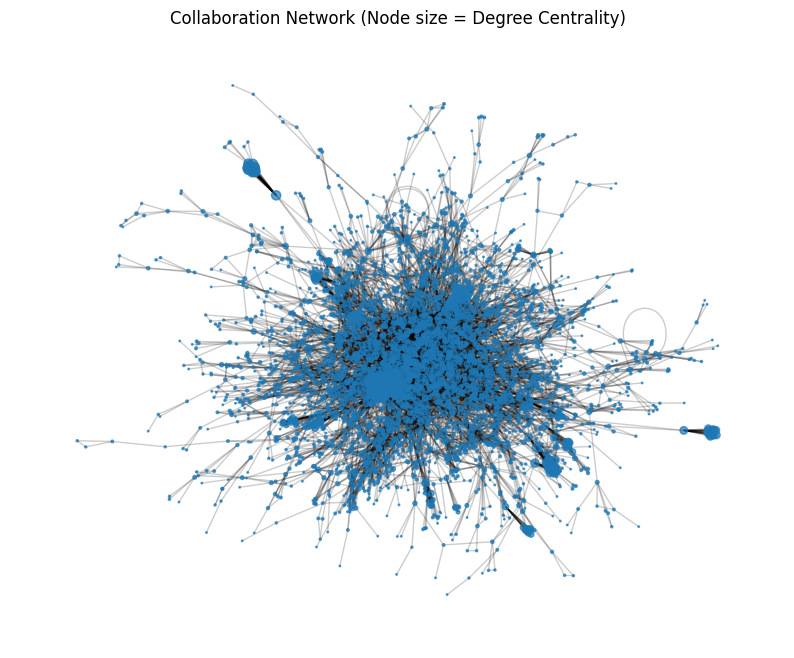

In [6]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_cali, seed=42)

node_sizes = [deg_cent_grqc[n] * 5000 for n in G_cali.nodes()]

nx.draw_networkx_nodes(G_cali, pos, node_size=node_sizes, alpha=0.7)
nx.draw_networkx_edges(G_cali, pos, alpha=0.2)

plt.title("Collaboration Network (Node size = Degree Centrality)")
plt.axis("off")
plt.show()

In [7]:
# Add centralities as node attributes
nx.set_node_attributes(G_cali, deg_cent_grqc, "degree_centrality")
nx.set_node_attributes(G_cali, bet_cent_grqc, "betweenness_centrality")
nx.set_node_attributes(G_cali, close_cent_grqc, "closeness_centrality")
nx.set_node_attributes(G_cali, eig_cent_grqc, "eigenvector_centrality")

# Export
nx.write_gexf(G_cali, "collaboration_with_centrality.gexf")

The centrality analysis of the CA-GrQc collaboration network shows that different measures capture different types of importance in academic collaborations. Degree and eigenvector centrality tend to highlight highly collaborative authors who are deeply embedded in the core of the research community. These authors likely work with many well-connected researchers and may represent senior scholars or central figures within major research groups. Their high eigenvector scores suggest they are not only active collaborators, but also connected to other influential authors.

In contrast, betweenness and closeness centrality reveal a different type of structural role. Authors with high betweenness appear to act as bridges between different collaboration clusters, possibly connecting separate subfields or research groups. These individuals may play an important role in interdisciplinary knowledge exchange. Closeness centrality highlights authors who are positioned near the structural center of the network, allowing them to reach others efficiently. Overall, the results show that importance in a collaboration network can reflect productivity, influence within the core community, or the ability to connect otherwise separate groups.

### Added: Erdos1 Collaboration Network  
Since the GRQC network doesn't contain author info. We added the Erdos1 Network

In [7]:
import re
import pandas as pd
import networkx as nx


def parse_erdos1_graph(filepath):
    """
    Parse the Erdos1 Graph text file into a NetworkX graph.

    File structure:
    - explanation lines
    - one line with number of vertices, e.g. "511"
    - then repeated blocks:
        header line: <seq> <degree> <num_outside> <author name>
        adjacency lines: one or more lines containing exactly <degree> neighbor IDs in total
    """

    with open(filepath, "r", encoding="utf-8") as f:
        lines = [line.rstrip("\n") for line in f]

    # 1. find the line containing only the number of vertices
    start_idx = None
    n = None
    for i, line in enumerate(lines):
        s = line.strip()
        if re.fullmatch(r"\d+", s):
            n = int(s)
            start_idx = i + 1
            break

    if n is None:
        raise ValueError("Could not find the number-of-vertices line.")

    # 2. parse each node block
    id_to_name = {}
    neighbors_dict = {}

    idx = start_idx
    parsed_count = 0

    while parsed_count < n and idx < len(lines):
        line = lines[idx].strip()

        # skip empty lines
        if not line:
            idx += 1
            continue

        # header format:
        # seq degree something name...
        # example:
        # 1 7 16 ABBOTT, HARVEY LESLIE
        m = re.match(r"^(\d+)\s+(\d+)\s+(\d+)\s+(.+)$", line)
        if not m:
            raise ValueError(f"Header parse failed at line {idx+1}: {lines[idx]}")

        node_id = int(m.group(1))
        degree = int(m.group(2))
        # third field = number of coauthors outside this subgraph, usually not needed
        name = m.group(4).strip()

        id_to_name[node_id] = name
        idx += 1

        # 3. read adjacency numbers until we have exactly `degree` neighbors
        nbrs = []
        while len(nbrs) < degree:
            if idx >= len(lines):
                raise ValueError(f"Unexpected EOF while reading neighbors for node {node_id} ({name})")

            nbr_line = lines[idx].strip()
            idx += 1

            if not nbr_line:
                continue

            nums = [int(x) for x in nbr_line.split()]
            nbrs.extend(nums)

        if len(nbrs) > degree:
            raise ValueError(
                f"Too many neighbors read for node {node_id} ({name}). "
                f"Expected {degree}, got {len(nbrs)}"
            )

        neighbors_dict[node_id] = nbrs
        parsed_count += 1

    if parsed_count != n:
        raise ValueError(f"Parsed {parsed_count} nodes, expected {n}")

    # 4. build graph with author names as node labels
    G = nx.Graph()

    for node_id, name in id_to_name.items():
        G.add_node(node_id, name=name)

    for u_id, nbr_ids in neighbors_dict.items():
        for v_id in nbr_ids:
            G.add_edge(u_id, v_id)

    return G, id_to_name, neighbors_dict


# ===== usage =====
file_path = "models/Erdos1_clean.txt"
Erdos, id_to_name, neighbors_dict = parse_erdos1_graph(file_path)

In [2]:
print("Erdos1 Network:")
print("Number of nodes:", Erdos.number_of_nodes())
print("Number of edges:", Erdos.number_of_edges())
print("Is directed:", Erdos.is_directed())
print("Is connected:", nx.is_connected(Erdos))

Erdos1 Network:
Number of nodes: 511
Number of edges: 1604
Is directed: False
Is connected: False


In [3]:
# Extract largest connected component
largest_cc = max(nx.connected_components(Erdos), key=len)
G_Erdos = Erdos.subgraph(largest_cc).copy()

print("Largest Connected Component:")
print("Nodes:", G_Erdos.number_of_nodes())
print("Edges:", G_Erdos.number_of_edges())

Largest Connected Component:
Nodes: 466
Edges: 1600


Using the Largest Conenctec Component seems to shrink the network alot. Let's proceed with original.

In [4]:
# Degree Centrality
deg_cent_erdos = nx.degree_centrality(Erdos)

# Betweenness Centrality
bet_cent_erdos = nx.betweenness_centrality(Erdos)

# Closeness Centrality
close_cent_erdos = nx.closeness_centrality(Erdos)

# Eigenvector Centrality
eig_cent_erdos = nx.eigenvector_centrality(Erdos, max_iter=1000)

In [5]:
def top_k(cent_dict, k=5):
    return sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:k]

top_degree = top_k(deg_cent_erdos)
top_between = top_k(bet_cent_erdos)
top_close = top_k(close_cent_erdos)
top_eigen = top_k(eig_cent_erdos)

print("Top 5 Degree Centrality:")
print(top_degree)

print("\nTop 5 Betweenness Centrality:")
print(top_between)

print("\nTop 5 Closeness Centrality:")
print(top_close)

print("\nTop 5 Eigenvector Centrality:")
print(top_eigen)

Top 5 Degree Centrality:
[(10, 0.1), (165, 0.08627450980392157), (187, 0.08627450980392157), (378, 0.08235294117647059), (479, 0.07647058823529412)]

Top 5 Betweenness Centrality:
[(187, 0.07551268517136107), (438, 0.06853455090759024), (449, 0.0662253907846568), (385, 0.06595332384225157), (355, 0.06291529322305747)]

Top 5 Closeness Centrality:
[(10, 0.35272095527062736), (165, 0.35272095527062736), (148, 0.34923442194011045), (44, 0.3444115257800927), (438, 0.3438528696149993)]

Top 5 Eigenvector Centrality:
[(10, 0.26319491157207014), (378, 0.2324650275258854), (165, 0.21275136875615522), (148, 0.19484950888434405), (479, 0.18781103102704205)]


In [8]:
# Combine into one dataframe
df = pd.DataFrame({
    "Degree": pd.Series(deg_cent_erdos),
    "Betweenness": pd.Series(bet_cent_erdos),
    "Closeness": pd.Series(close_cent_erdos),
    "Eigenvector": pd.Series(eig_cent_erdos)
})

# add author name using id_to_name
df["Author"] = df.index.map(id_to_name)

# optional: move Author column to front
df = df[["Author", "Degree", "Betweenness", "Closeness", "Eigenvector"]]

# Sort by degree
df_sorted = df.sort_values("Degree", ascending=False)

df_sorted.head(10)

,Author,Degree,Betweenness,Closeness,Eigenvector
10,"ALON, NOGA M.",0.100000,0.056014,0.352721,0.263195
187,"HARARY, FRANK*",0.086275,0.075513,0.330453,0.130325
165,"GRAHAM, RONALD LEWIS",0.086275,0.054525,0.352721,0.212751
378,"RODL, VOJTECH",0.082353,0.028210,0.334890,0.232465
479,"TUZA, ZSOLT",0.076471,0.043305,0.338095,0.187811
44,"BOLLOBAS, BELA",0.072549,0.046794,0.344412,0.172466
438,"SOS, VERA TURAN",0.072549,0.068535,0.343853,0.128078
148,"FUREDI, ZOLTAN",0.070588,0.050996,0.349234,0.194850
440,"SPENCER, JOEL H.",0.068627,0.029566,0.335685,0.187509
341,"PACH, JANOS",0.062745,0.047604,0.329170,0.157713


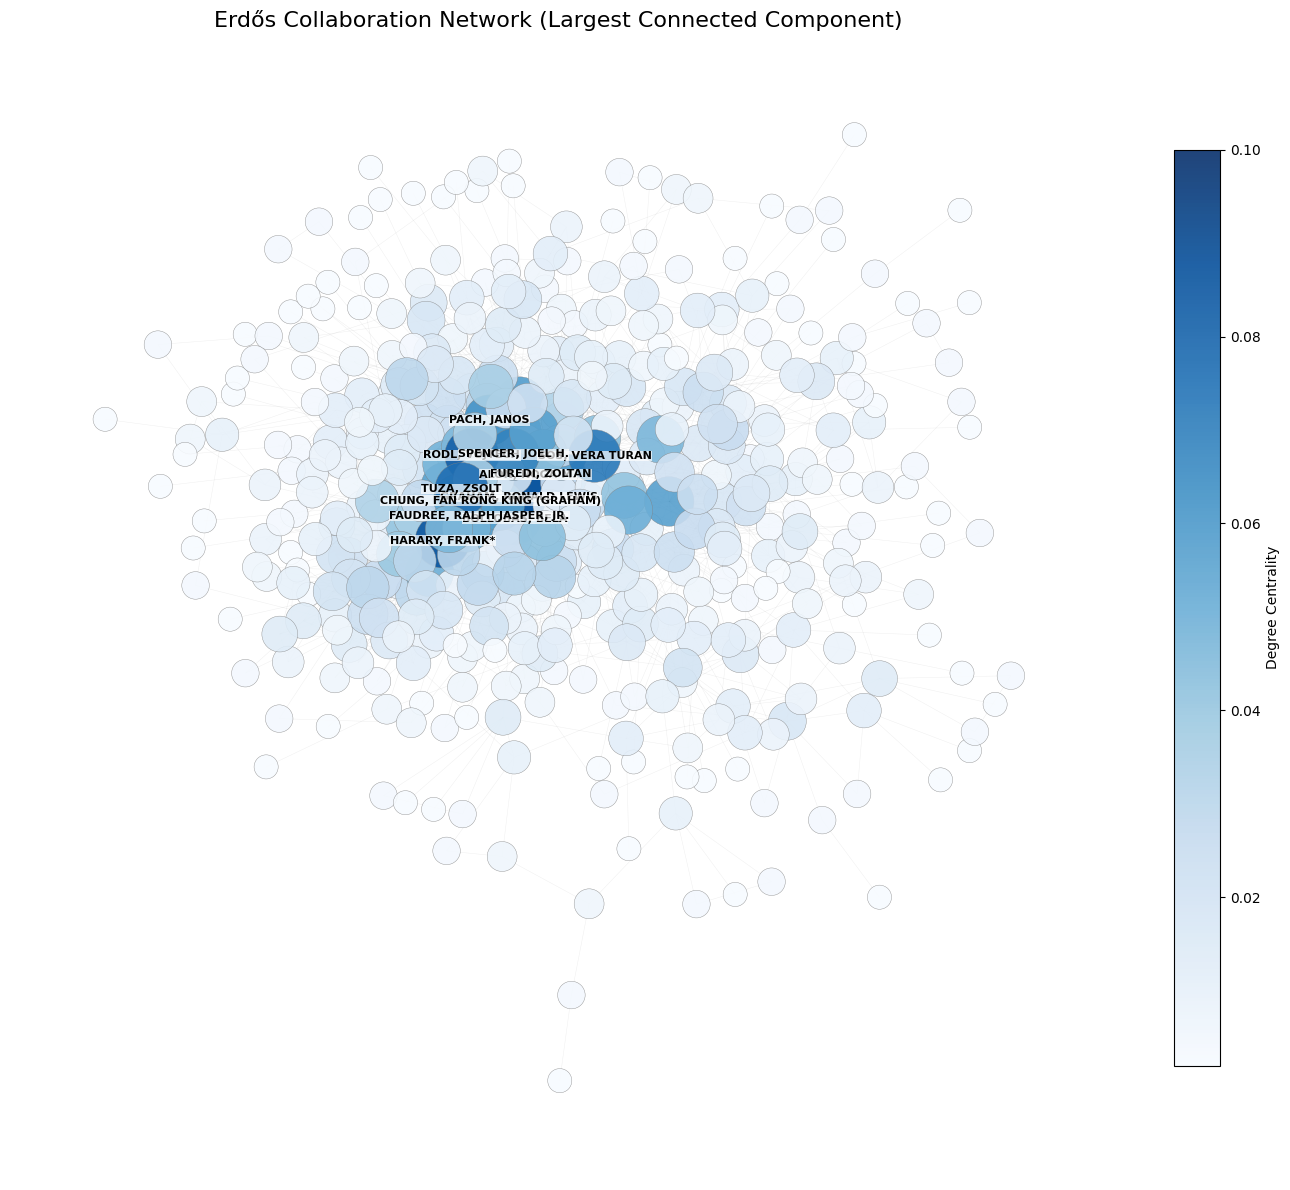

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np

# ========= 1. 只取最大连通分量 =========
largest_cc = max(nx.connected_components(Erdos), key=len)
G = Erdos.subgraph(largest_cc).copy()

# 如果你的 centrality 是对整个图算的，也可以直接沿用
deg_cent = {n: deg_cent_erdos[n] for n in G.nodes()}
bet_cent = {n: bet_cent_erdos[n] for n in G.nodes()}
close_cent = {n: close_cent_erdos[n] for n in G.nodes()}
eig_cent = {n: eig_cent_erdos[n] for n in G.nodes()}

# ========= 2. 写入属性 =========
nx.set_node_attributes(G, {n: id_to_name.get(n, str(n)) for n in G.nodes()}, "author")
nx.set_node_attributes(G, deg_cent, "degree_centrality")
nx.set_node_attributes(G, bet_cent, "betweenness_centrality")
nx.set_node_attributes(G, close_cent, "closeness_centrality")
nx.set_node_attributes(G, eig_cent, "eigenvector_centrality")

# ========= 3. 布局 =========
# 方案 A: 更稳定更好看
pos = nx.kamada_kawai_layout(G)

# 如果觉得慢，可以换成下面这个：
# pos = nx.spring_layout(G, seed=42, k=0.35, iterations=300)

# ========= 4. 节点大小，非线性缩放 =========
node_vals = np.array([deg_cent[n] for n in G.nodes()])
node_sizes = 80 + 5000 * np.sqrt(node_vals)

# ========= 5. 节点颜色 =========
norm = mcolors.Normalize(vmin=node_vals.min(), vmax=node_vals.max())
node_colors = [deg_cent[n] for n in G.nodes()]

# ========= 6. 画图 =========
plt.figure(figsize=(14, 12))

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.06,
    width=0.4
)

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Blues,
    alpha=0.9,
    linewidths=0.3,
    edgecolors="gray"
)

# ========= 7. 只标 top 12 =========
top_k = 12
top_nodes = sorted(deg_cent, key=deg_cent.get, reverse=True)[:top_k]

labels = {n: id_to_name.get(n, str(n)) for n in top_nodes}

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8,
    font_weight="bold",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.2)
)

plt.title("Erdős Collaboration Network (Largest Connected Component)", fontsize=16)
plt.axis("off")

cbar = plt.colorbar(nodes, shrink=0.8)
cbar.set_label("Degree Centrality")

plt.tight_layout()
plt.show()

In [10]:
# Add centralities as node attributes

#nx.set_node_attributes(Erdos, id_to_name, "author")
nx.set_node_attributes(Erdos, deg_cent_erdos, "degree_centrality")
nx.set_node_attributes(Erdos, bet_cent_erdos, "betweenness_centrality")
nx.set_node_attributes(Erdos, close_cent_erdos, "closeness_centrality")
nx.set_node_attributes(Erdos, eig_cent_erdos, "eigenvector_centrality")

# Export
nx.write_gexf(Erdos, "erdos1_collaboration_with_centrality.gexf")

The Erdős collaboration network shows a clear core–periphery structure. Most of the highly connected authors are located near the center of the graph, forming a dense cluster of collaborations, while many smaller nodes appear toward the outer region. Nodes with higher degree centrality are both larger and darker in the visualization, indicating that a small number of researchers collaborate with many others and act as hubs within the network. This pattern suggests that mathematical collaboration tends to concentrate around a few well connected individuals.

From the centrality results, authors such as Noga M. Alon, Frank Harary, Ronald Graham, and Béla Bollobás appear among the most central nodes. These researchers have high degree and relatively strong eigenvector centrality, meaning they not only collaborate widely but also tend to collaborate with other well connected mathematicians. As a result, they occupy structurally important positions in the network and help connect different groups of researchers.

Overall, the graph reflects the collaborative nature of the mathematics community around Paul Erdős. A small group of influential researchers forms the core of the network, while many others connect through them in smaller collaboration chains. This structure helps information and ideas spread efficiently across the community, since highly connected scholars serve as bridges linking multiple research groups.

### (b) Facebook Network

In [16]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Fackbook network
facebook = nx.read_edgelist("models/facebook_combined.txt")

print("Facebook Network:")
print("Number of nodes:", facebook.number_of_nodes())
print("Number of edges:", facebook.number_of_edges())
print("Is directed:", facebook.is_directed())
print("Is connected:", nx.is_connected(facebook))

Facebook Network:
Number of nodes: 4039
Number of edges: 88234
Is directed: False
Is connected: True


We see that the model is fully connected.

Again, let's look at the centralities

In [17]:
# Degree centrality
deg_cent_fb = nx.degree_centrality(facebook)

# Betweenness centrality (can be slow for large graphs)
bet_cent_fb = nx.betweenness_centrality(facebook)

# Closeness centrality
close_cent_fb = nx.closeness_centrality(facebook)

# Eigenvector centrality
eig_cent_fb = nx.eigenvector_centrality(facebook, max_iter=2000)

Sort the top-5 result in a list

In [18]:
def top_k(cent_dict, k=5):
    return sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:k]

top_deg_fb = top_k(deg_cent_fb, k=5)
top_bet_fb = top_k(bet_cent_fb, k=5)
top_close_fb = top_k(close_cent_fb, k=5)
top_eig_fb = top_k(eig_cent_fb, k=5)

print("Top 5 Degree Centrality:\n", top_deg_fb)
print("\nTop 5 Betweenness Centrality:\n", top_bet_fb)
print("\nTop 5 Closeness Centrality:\n", top_close_fb)
print("\nTop 5 Eigenvector Centrality:\n", top_eig_fb)

Top 5 Degree Centrality:
 [('107', 0.258791480931154), ('1684', 0.1961367013372957), ('1912', 0.18697374938088163), ('3437', 0.13546310054482416), ('0', 0.08593363051015354)]

Top 5 Betweenness Centrality:
 [('107', 0.4805180785560152), ('1684', 0.3377974497301992), ('3437', 0.23611535735892905), ('1912', 0.2292953395868782), ('1085', 0.14901509211665306)]

Top 5 Closeness Centrality:
 [('107', 0.45969945355191255), ('58', 0.3974018305284913), ('428', 0.3948371956585509), ('563', 0.3939127889961955), ('1684', 0.39360561458231796)]

Top 5 Eigenvector Centrality:
 [('1912', 0.09540696149067629), ('2266', 0.08698327767886552), ('2206', 0.08605239270584342), ('2233', 0.08517340912756598), ('2464', 0.08427877475676092)]


In [19]:
df_fb = pd.DataFrame({
    "Degree": pd.Series(deg_cent_fb),
    "Betweenness": pd.Series(bet_cent_fb),
    "Closeness": pd.Series(close_cent_fb),
    "Eigenvector": pd.Series(eig_cent_fb)
})

df_fb_sorted = df_fb.sort_values("Degree", ascending=False)
df_fb_sorted.head(10)

,Degree,Betweenness,Closeness,Eigenvector
107,0.258791,0.480518,0.459699,2.606940e-04
1684,0.196137,0.337797,0.393606,7.164260e-06
1912,0.186974,0.229295,0.350947,9.540696e-02
3437,0.135463,0.236115,0.314413,9.531613e-08
0,0.085934,0.146306,0.353343,3.391796e-05
2543,0.072808,0.007605,0.291300,7.287131e-02
2347,0.072065,0.003200,0.283408,8.032160e-02
1888,0.062902,0.000118,0.321292,1.060441e-04
1800,0.060674,0.000153,0.321599,1.019310e-04
1663,0.058197,0.001100,0.339185,1.285378e-04


Let's visualize the Facebook Network

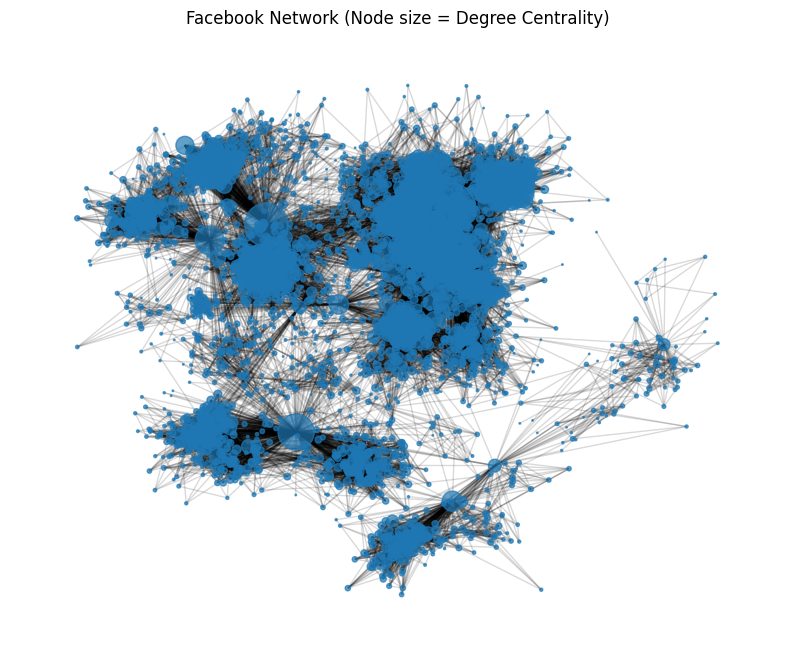

In [20]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(facebook, seed=42)

node_sizes = [deg_cent_fb[n] * 5000 for n in facebook.nodes()]

nx.draw_networkx_nodes(facebook, pos, node_size=node_sizes, alpha=0.7)
nx.draw_networkx_edges(facebook, pos, alpha=0.15)

plt.title("Facebook Network (Node size = Degree Centrality)")
plt.axis("off")
plt.show()

In [21]:
nx.set_node_attributes(facebook, deg_cent_fb, "degree_centrality")
nx.set_node_attributes(facebook, bet_cent_fb, "betweenness_centrality")
nx.set_node_attributes(facebook, close_cent_fb, "closeness_centrality")
nx.set_node_attributes(facebook, eig_cent_fb, "eigenvector_centrality")

nx.write_gexf(facebook, "facebook_with_centrality.gexf")
print("Exported: facebook_with_centrality.gexf")

Exported: facebook_with_centrality.gexf


The Facebook network shows a clear community structure, with several dense clusters connected by a smaller number of bridging nodes. Degree centrality highlights users with many friends, who appear as large nodes inside dense clusters. These individuals likely represent socially active users within specific communities. However, high degree does not always mean structural importance across the whole network.

Betweenness centrality identifies a different type of node: users that connect otherwise separate clusters. These nodes may not have the highest number of friends, but they play a key role in linking different social groups. Closeness centrality tends to highlight users located near the structural center of the network, allowing them to reach others efficiently. Overall, the results suggest that importance in a social network can reflect popularity within a group, or the ability to connect multiple communities across the network.

### (c) E-mail Network

In [16]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load email network
email = nx.read_edgelist("models/Email-Enron.txt", create_using=nx.DiGraph())

print("E-mail Network:")
print("Number of nodes:", email.number_of_nodes())
print("Number of edges:", email.number_of_edges())
print("Is directed:", email.is_directed())
print("Is weakly connected:", nx.is_weakly_connected(email))
print("Is strongly connected:", nx.is_strongly_connected(email))

E-mail Network:
Number of nodes: 36692
Number of edges: 367662
Is directed: True
Is weakly connected: False
Is strongly connected: False


Since this network is directed and not fully connected, we extract it's largest weakly connected component.

In [17]:
largest_wcc = max(nx.weakly_connected_components(email), key=len)
G_email = email.subgraph(largest_wcc).copy()

print("Largest Weakly Connected Component:")
print("Nodes:", G_email.number_of_nodes())
print("Edges:", G_email.number_of_edges())

Largest Weakly Connected Component:
Nodes: 33696
Edges: 361622


We can see that using largest weakly connected component does not shrink the graph too much

In [18]:
# In/Out degree centrality
in_deg_cent  = nx.in_degree_centrality(G_email)
out_deg_cent = nx.out_degree_centrality(G_email)

# Closeness centrality
close_cent_fb = nx.closeness_centrality(G_email)

# Eigenvector centrality
eig_cent_fb = nx.eigenvector_centrality(G_email, max_iter=2000)

In [19]:
# Approximate betweenness using k sampled sources
k = 5000  
bet_cent_approx = nx.betweenness_centrality(G_email, k=k, seed=42, normalized=True)


In [20]:
def top_k(cent_dict, k=5):
    return sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:k]

print("Top 5 In-Degree Centrality:\n", top_k(in_deg_cent, 5))
print("\nTop 5 Out-Degree Centrality:\n", top_k(out_deg_cent, 5))
print("\nTop 5 Closeness Centrality:\n", top_k(close_cent_fb, 5))
print("\nTop 5 Eigenvector Centrality:\n", top_k(eig_cent_fb, 5))
print("\nTop 5 Betweenness:\n", top_k(bet_cent_approx, 5))

Top 5 In-Degree Centrality:
 [('5038', 0.04104466538062027), ('273', 0.040569817480338326), ('458', 0.03742395014097047), ('140', 0.03694910224068853), ('1028', 0.03691942424692091)]

Top 5 Out-Degree Centrality:
 [('5038', 0.04104466538062027), ('273', 0.040569817480338326), ('458', 0.03742395014097047), ('140', 0.03694910224068853), ('1028', 0.03691942424692091)]

Top 5 Closeness Centrality:
 [('136', 0.3873700910512278), ('76', 0.3861183049526734), ('46', 0.3790810701347794), ('140', 0.37475531630928016), ('370', 0.374522052285257)]

Top 5 Eigenvector Centrality:
 [('136', 0.14956143435991484), ('195', 0.1270762961101755), ('76', 0.12645874758171832), ('370', 0.12131422994248223), ('1028', 0.11241049559837275)]

Top 5 Betweenness:
 [('5038', 0.07667637290693823), ('140', 0.07175449640039112), ('566', 0.04309602207200748), ('1139', 0.042213135206678944), ('273', 0.041522778269076036)]


In [21]:
df_email = pd.DataFrame({
    "InDegree": pd.Series(in_deg_cent),
    "OutDegree": pd.Series(out_deg_cent),
    "Closeness": pd.Series(close_cent_fb),
    "Eigenvector": pd.Series(eig_cent_fb),
    "Betweenness": pd.Series(bet_cent_approx),
})

df_email_sorted = df_email.sort_values("Eigenvector", ascending=False)
df_email_sorted.head(10)

,InDegree,OutDegree,Closeness,Eigenvector,Betweenness
136,0.030450,0.030450,0.387370,0.149561,0.024837
195,0.033922,0.033922,0.373990,0.127076,0.030971
76,0.024188,0.024188,0.386118,0.126459,0.022915
370,0.032616,0.032616,0.374522,0.121314,0.027728
1028,0.036919,0.036919,0.366992,0.112410,0.033579
273,0.040570,0.040570,0.365158,0.112069,0.041523
734,0.020359,0.020359,0.373957,0.104399,0.020122
416,0.023475,0.023475,0.372341,0.100537,0.018970
175,0.014720,0.014720,0.373791,0.098898,0.012851
292,0.024751,0.024751,0.374335,0.097488,0.029525


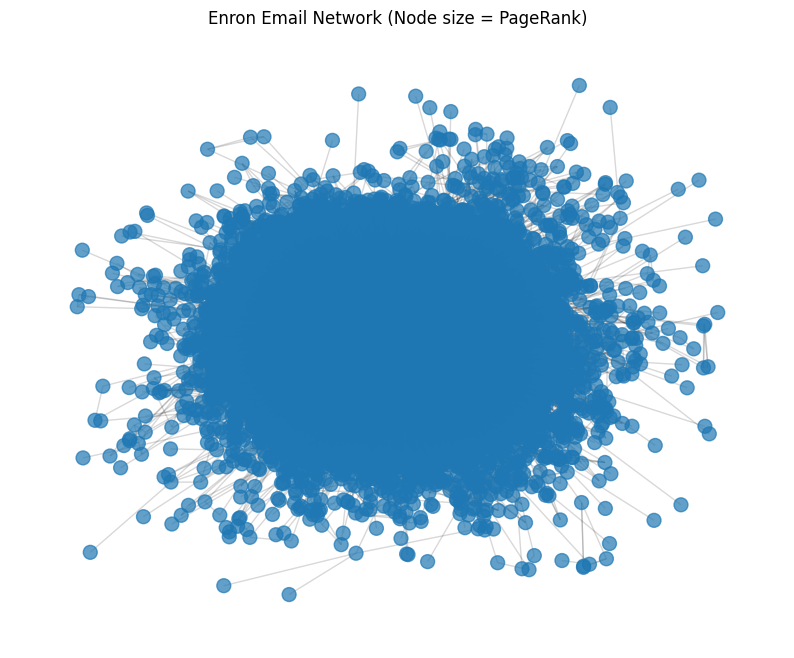

In [22]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_email, seed=42)

sizes = np.array([eig_cent_fb[n] for n in G_email.nodes()])
sizes = 2000 * (sizes / sizes.max() + 0.05)

nx.draw_networkx_nodes(G_email, pos, node_size=sizes, alpha=0.7)
nx.draw_networkx_edges(G_email, pos, alpha=0.08, arrows=False)  # arrows off for readability

plt.title("Enron Email Network (Node size = PageRank)")
plt.axis("off")
plt.show()

In [24]:
nx.set_node_attributes(G_email, in_deg_cent, "in_degree_centrality")
nx.set_node_attributes(G_email, out_deg_cent, "out_degree_centrality")
nx.set_node_attributes(G_email, close_cent_fb, "closeness_centrality")
nx.set_node_attributes(G_email, eig_cent_fb, "eigenvector_centrality")
nx.set_node_attributes(G_email, bet_cent_approx, "betweeness_centrality")

nx.write_gexf(G_email, "enron_with_centrality.gexf")
print("Exported: enron_with_centrality.gexf")

Exported: enron_with_centrality.gexf


## 4. Top 10% Analysis

In [25]:
import networkx as nx

# Load graphs
collab = nx.read_gexf("collaboration_with_centrality.gexf")
enron = nx.read_gexf("enron_with_centrality.gexf")
facebook = nx.read_gexf("facebook_with_centrality.gexf")
erdos = nx.read_gexf("erdos1_collaboration_with_centrality.gexf")

print(collab.number_of_nodes(), enron.number_of_nodes(), facebook.number_of_nodes(), erdos.number_of_nodes())

4158 33696 4039 511


In [26]:
def centrality_overlap(G, deg_attr="degree_centrality", bet_attr="betweenness_centrality"):
    
    n = G.number_of_nodes()
    k = max(1, int(n * 0.10))   # top 10%

    # Extract values
    deg = {node: G.nodes[node].get(deg_attr, 0) for node in G.nodes()}
    bet = {node: G.nodes[node].get(bet_attr, 0) for node in G.nodes()}

    # Sort nodes
    top_deg = sorted(deg, key=deg.get, reverse=True)[:k]
    top_bet = sorted(bet, key=bet.get, reverse=True)[:k]

    # Convert to sets
    top_deg = set(top_deg)
    top_bet = set(top_bet)

    overlap = top_deg & top_bet

    return {
        "nodes": n,
        "top_10_percent": k,
        "overlap_count": len(overlap),
        "overlap_nodes": overlap
    }

In [27]:
results = {
    "Collaboration": centrality_overlap(collab),
    "Enron Email": centrality_overlap(enron),
    "Facebook": centrality_overlap(facebook),
    "Erdos Collaboration": centrality_overlap(erdos)
}

results

{'Collaboration': {'nodes': 4158,
  'top_10_percent': 415,
  'overlap_count': 191,
  'overlap_nodes': {'1000',
   '10055',
   '10096',
   '10130',
   '1023',
   '10711',
   '10762',
   '10791',
   '11275',
   '11372',
   '11400',
   '11557',
   '11696',
   '11785',
   '11861',
   '1217',
   '12212',
   '12365',
   '12491',
   '12545',
   '12587',
   '12781',
   '12842',
   '12927',
   '13008',
   '13096',
   '13142',
   '13276',
   '13384',
   '13404',
   '13520',
   '13556',
   '13597',
   '13614',
   '13801',
   '13929',
   '14265',
   '14430',
   '14485',
   '14599',
   '14746',
   '14807',
   '1488',
   '14924',
   '15003',
   '15066',
   '15108',
   '15244',
   '15300',
   '15455',
   '15552',
   '1588',
   '16032',
   '16148',
   '16310',
   '16389',
   '16414',
   '1653',
   '16994',
   '17038',
   '17075',
   '17439',
   '17626',
   '17655',
   '18208',
   '18487',
   '18866',
   '18940',
   '19297',
   '19423',
   '19489',
   '1958',
   '19640',
   '19865',
   '19992',
   '203

In [14]:
for name, r in results.items():
    print(f"\n{name}")
    print("-----------------------")
    print("Total nodes:", r["nodes"])
    print("Top 10% size:", r["top_10_percent"])
    print("Overlap count:", r["overlap_count"])


Collaboration
-----------------------
Total nodes: 4158
Top 10% size: 415
Overlap count: 191

Enron Email
-----------------------
Total nodes: 33696
Top 10% size: 3369
Overlap count: 3369

Facebook
-----------------------
Total nodes: 4039
Top 10% size: 403
Overlap count: 105

Erdos Collaboration
-----------------------
Total nodes: 511
Top 10% size: 51
Overlap count: 31


In [ ]:
for name, r in results.items():
    ratio = r["overlap_count"] / r["top_10_percent"]
    print(f"{name}: {ratio:.2f} overlap ratio")

Collaboration: 0.46 overlap ratio
Enron Email: 1.00 overlap ratio
Facebook: 0.26 overlap ratio
Erdos Collaboration: 0.61 overlap ratio


: 

### Overlap Between Degree and Betweenness Centrality

We compared the top 10% of nodes ranked by degree centrality and betweenness centrality in each network to examine how often highly connected nodes also serve as important bridges. The Enron email network shows a complete overlap, where all nodes in the top 10% by degree centrality are also in the top 10% by betweenness centrality. This suggests that the most connected individuals in the email network also play key roles in connecting different parts of the communication structure.

The other networks show varying levels of overlap. The Erdős collaboration network has a relatively high overlap ratio of about 0.61, indicating that many highly connected researchers also act as intermediaries linking different groups of collaborators. The general collaboration network has a moderate overlap of about 0.46, suggesting that some highly connected authors are also bridges, but not all.

The Facebook network shows the lowest overlap at about 0.26. This implies that having many friends does not necessarily mean a user connects different communities. Some users may have many connections within a single group, while others with fewer connections may serve as bridges between different social clusters.

Betweenness centrality for the Enron email network was computed using a sampling-based approximation due to the large size of the graph. Because only a subset of nodes was used as sources for shortest-path calculations, the approximation tends to favor high-degree nodes that appear frequently in sampled paths. This likely explains the unusually high overlap between the top nodes ranked by degree and betweenness centrality.